# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-10: Desigualdad de Bell — Juego CHSH (Cirq)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-10.

---

### El juego de cooperación

Alice y Bob juegan contra un árbitro siguiendo estas reglas:

1. El árbitro envía un bit $x_1 \in \{0,1\}$ a Alice y un bit $x_2 \in \{0,1\}$ a Bob de forma **independiente y aleatoria**.
2. Alice responde con un bit $a(x_1)$ y Bob con un bit $b(x_2)$, **sin poder comunicarse entre sí**.
3. **Ganan** si: $a(x_1) \oplus b(x_2) = x_1 \cdot x_2$

La regla en palabras directas: **casi siempre deben responder lo mismo, excepto cuando los dos reciben 1**:

| $x_1$ | $x_2$ | Condición de victoria | Intuición |
|:---:|:---:|:---:|---|
| 0 | 0 | $a = b$ | mismos bits |
| 0 | 1 | $a = b$ | mismos bits |
| 1 | 0 | $a = b$ | mismos bits |
| 1 | 1 | $a \neq b$ | bits distintos |

El $\oplus$ (XOR) es la forma matemática de decir "¿son distintos?": $a \oplus b = 0$ significa iguales, $a \oplus b = 1$ significa distintos.

---

### Por qué la regla es difícil

El árbitro diseñó la regla para que sea difícil de satisfacer siempre. Si Alice recibe 1, **no sabe** si Bob recibió 0 (debe coincidir) o 1 (debe diferir). Sin comunicación, no puede decidir correctamente en todos los casos.

---

### Por qué el 75% es el techo clásico

Cualquier estrategia clásica se puede escribir como dos funciones fijas: $a(x_1)$ y $b(x_2)$. Solo hay 4 combinaciones posibles:

| Estrategia | (0,0) | (0,1) | (1,0) | (1,1) | Victorias |
|---|:---:|:---:|:---:|:---:|:---:|
| $a=0, b=0$ | ✓ | ✓ | ✓ | ✗ | 3/4 |
| $a=1, b=1$ | ✓ | ✓ | ✓ | ✗ | 3/4 |
| $a=0, b=1$ | ✗ | ✗ | ✗ | ✓ | 1/4 |
| $a=1, b=0$ | ✗ | ✗ | ✗ | ✓ | 1/4 |

Las dos mejores estrategias clásicas ganan exactamente 3 de 4 veces. Mezclar estrategias aleatoriamente tampoco ayuda — un promedio ponderado de 75% y 25% nunca supera el 75%. Es un **límite duro**, no una limitación tecnológica.

---

### Qué cambia con el entrelazamiento

Cuando Alice y Bob comparten el estado de Bell $\frac{1}{\sqrt{2}}(\vert 00\rangle + \vert 11\rangle)$, sus qubits están correlacionados de una forma que no tiene equivalente clásico.

La clave es que pueden elegir el **ángulo de medición** en función del bit que reciben del árbitro:

| Jugador | Si recibe | Mide en la base |
|---|:---:|---|
| Alice | $x_1 = 0$ | base estándar ($0°$) |
| Alice | $x_1 = 1$ | base rotada $45°$ |
| Bob   | $x_2 = 0$ | base rotada $22.5°$ |
| Bob   | $x_2 = 1$ | base rotada $-22.5°$ |

Con estos ángulos las correlaciones cuánticas hacen que sus respuestas coincidan o difieran cuando el juego lo requiere con probabilidad:

$$P(\text{victoria}) = \cos^2\!\left(\frac{\pi}{8}\right) \approx 85.4\%$$

en **todos** los escenarios — superando el 75% clásico en cada uno de ellos.

---

### Por qué esto importa más allá del juego

El resultado de que ninguna estrategia clásica puede superar el 75% se llama **desigualdad de Bell** (John Bell, 1964). Fue derivada para responder una pregunta filosófica profunda: ¿la aleatoriedad cuántica es "real" o simplemente refleja información oculta que no conocemos?

Si existieran "variables ocultas locales" — instrucciones predeterminadas que los qubits llevan consigo — el juego no podría superar el 75%. El hecho de que el experimento real dé ~85% demuestra que **esas instrucciones ocultas no existen**. La aleatoriedad cuántica es irreducible.

Esto fue verificado experimentalmente múltiples veces, culminando en el experimento de Delft (2015) que cerró todas las brechas técnicas posibles. Aspect, Clauser y Zeilinger recibieron el **Nobel de Física 2022** por estos experimentos.

---

### Qubits del circuito

| Qubit | Rol |
|:---:|---|
| Q0 | Qubit de Alice (mitad del par de Bell) |
| Q1 | Bit del árbitro para Alice ($r_A = x_1$) |
| Q2 | Qubit de Bob (mitad del par de Bell) |
| Q3 | Bit del árbitro para Bob ($r_B = x_2$) |

### Circuito

In [1]:
import cirq
import numpy as np


def bell_inequality_test_circuit():
    """
    Construye el circuito del juego CHSH para probar la desigualdad de Bell.

    Q0: qubit de Alice   Q1: bit árbitro → Alice (r_A)
    Q2: qubit de Bob     Q3: bit árbitro → Bob   (r_B)
    """
    qubits = [cirq.LineQubit(i) for i in range(4)]
    circuit = cirq.Circuit()

    # Paso 1: crear el par de Bell |Φ+⟩ entre Alice (Q0) y Bob (Q2)
    # H(Q0) → superposición, CNOT(Q0→Q2) → entrelazamiento
    circuit.append([
        cirq.H(qubits[0]),
        cirq.CNOT(qubits[0], qubits[2]),
    ])

    # Paso 2: Alice aplica X^(-0.25) en su qubit
    # Rota la base de medición de Alice en -π/4 respecto a la base estándar
    circuit.append(cirq.X(qubits[0]) ** (-0.25))

    # Paso 3: el árbitro genera bits aleatorios para Alice y Bob con Hadamard
    # H sobre |0⟩ da superposición uniforme → al medir: 0 o 1 con prob. 0.5
    circuit.append([
        cirq.H(qubits[1]),  # r_A: bit aleatorio para Alice
        cirq.H(qubits[3]),  # r_B: bit aleatorio para Bob
    ])

    # Paso 4: rotación condicional en función del bit del árbitro
    # CNOT^0.5 (sqrt(CNOT)): si el bit del árbitro es 1, rota el qubit del jugador
    # Alice: si r_A=1 → rota Q0 en π/4 adicional (total π/4 desde el paso 2)
    circuit.append(cirq.CNOT(qubits[1], qubits[0]) ** 0.5)
    # Bob:   si r_B=1 → rota Q2 en π/4 (equivale a cambiar de base π/8 → -π/8)
    circuit.append(cirq.CNOT(qubits[3], qubits[2]) ** 0.5)

    # Paso 5: medir cada qubit con su propia clave para análisis separado
    circuit.append(cirq.measure(qubits[0], key='A'))    # respuesta de Alice
    circuit.append(cirq.measure(qubits[1], key='r_A'))  # bit árbitro Alice
    circuit.append(cirq.measure(qubits[2], key='B'))    # respuesta de Bob
    circuit.append(cirq.measure(qubits[3], key='r_B'))  # bit árbitro Bob

    return circuit

In [2]:
circuit = bell_inequality_test_circuit()
print(circuit)

0: ───H───@───X^-0.25───X^0.5──────M('A')─────
          │             │
1: ───H───┼─────────────@──────────M('r_A')───
          │
2: ───────X───X^0.5─────M('B')────────────────
              │
3: ───H───────@─────────M('r_B')──────────────


### Visualización del circuito

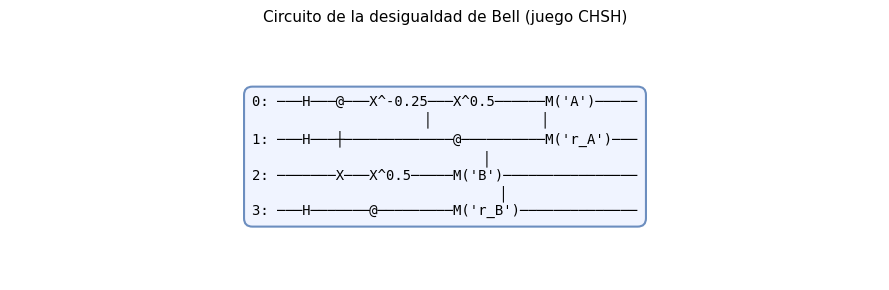

In [3]:
import matplotlib.pyplot as plt

diagrama = circuit.to_text_diagram()

fig, ax = plt.subplots(figsize=(9, 3))
ax.text(
    0.5, 0.5, diagrama,
    fontfamily='monospace', fontsize=10,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f4ff', edgecolor='#6c8ebf', linewidth=1.5),
)
ax.axis('off')
ax.set_title('Circuito de la desigualdad de Bell (juego CHSH)', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

### Simulación y tasa de victoria

**Condición de victoria:** $a \oplus b = r_A \cdot r_B$, equivalente a:
$$( A + B ) \bmod 2 = r_A \mathbin{\&} r_B$$

In [4]:
ITERS = 1000

sim = cirq.Simulator()
result = sim.run(circuit, repetitions=ITERS)

# Extraer los bits medidos para cada qubit
A   = result.measurements['A'][:, 0]    # respuesta de Alice
r_A = result.measurements['r_A'][:, 0]  # bit árbitro Alice
B   = result.measurements['B'][:, 0]    # respuesta de Bob
r_B = result.measurements['r_B'][:, 0]  # bit árbitro Bob

# Condición de victoria: (A XOR B) == (r_A AND r_B)
win = (A + B) % 2 == (r_A & r_B)

tasa_victoria = 100 * np.mean(win)
limite_clasico = 75.0
limite_cuantico = 100 * np.cos(np.pi / 8) ** 2

print(f"Tasa de victoria cuántica:    {tasa_victoria:.1f}%")
print(f"Límite clásico (máximo):       {limite_clasico:.1f}%")
print(f"Límite cuántico teórico:       {limite_cuantico:.1f}%")
print(f"Violación de la desigualdad:   {'SÍ' if tasa_victoria > limite_clasico else 'NO'}")

Tasa de victoria cuántica:    84.1%
Límite clásico (máximo):       75.0%
Límite cuántico teórico:       85.4%
Violación de la desigualdad:   SÍ


### Tasa de victoria por combinación de bits del árbitro

Verificamos que la ventaja cuántica aparece en todos los escenarios, especialmente cuando $r_A = r_B = 1$ (el caso más difícil para la estrategia clásica).

In [5]:
escenarios = [(0, 0), (0, 1), (1, 0), (1, 1)]
tasas = []
etiquetas = []

for ra, rb in escenarios:
    mascara = (r_A == ra) & (r_B == rb)
    if mascara.sum() > 0:
        tasa = 100 * win[mascara].mean()
    else:
        tasa = 0.0
    tasas.append(tasa)
    etiquetas.append(f'$r_A={ra}, r_B={rb}$')
    print(f"r_A={ra}, r_B={rb}: {mascara.sum():4d} casos → victoria {tasa:.1f}%")

print(f"\nVictoria global: {tasa_victoria:.1f}%")

r_A=0, r_B=0:  248 casos → victoria 85.5%
r_A=0, r_B=1:  259 casos → victoria 83.4%
r_A=1, r_B=0:  262 casos → victoria 83.6%
r_A=1, r_B=1:  231 casos → victoria 84.0%

Victoria global: 84.1%


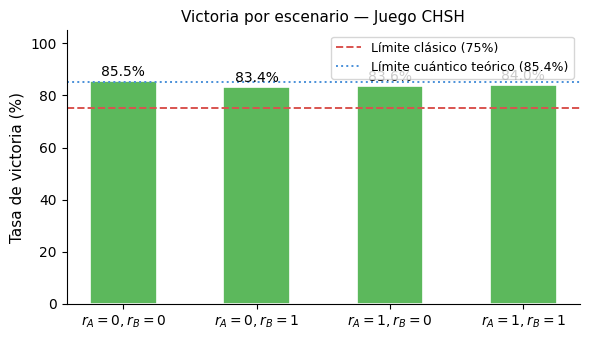

In [6]:
colores = ['#5cb85c' if t > limite_clasico else '#d9534f' for t in tasas]

fig, ax = plt.subplots(figsize=(6, 3.5))
barras = ax.bar(etiquetas, tasas, color=colores, edgecolor='white', linewidth=1.2, width=0.5)

ax.axhline(limite_clasico, color='#d9534f', linestyle='--', linewidth=1.4,
           label=f'Límite clásico ({limite_clasico:.0f}%)')
ax.axhline(limite_cuantico, color='#4a90d9', linestyle=':', linewidth=1.4,
           label=f'Límite cuántico teórico ({limite_cuantico:.1f}%)')

for barra, t in zip(barras, tasas):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.8,
            f'{t:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Tasa de victoria (%)', fontsize=11)
ax.set_title('Victoria por escenario — Juego CHSH', fontsize=11)
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretación

Las barras verdes superan el límite clásico del 75% en todos los escenarios — evidencia de la **violación de la desigualdad de Bell**.

**¿Por qué importa?**
- Demuestra que el entrelazamiento cuántico no puede replicarse con ninguna variable oculta local.
- Es la base experimental de la **criptografía cuántica** (QKD): si Eve intercepta los qubits, el entrelazamiento se rompe y la tasa de victoria cae por debajo del 75%, delatando la escucha.
- La violación de Bell fue verificada experimentalmente por Aspect et al. (1982) y confirmada sin brechas por Hensen et al. (2015), ganando el Nobel de Física 2022.